# Проверка гипотез в бизнесе: анализ сервиса проката самокатов

## Описание исследования

В проекте проведён анализ данных сервиса проката самокатов. Исследование направлено на изучение демографического профиля пользователей, особенностей использования сервиса и оценку эффективности платной подписки Ultra. Дополнительно выполнена проверка статистических гипотез и моделирование распределений для поддержки продуктовых и финансовых решений.

## Цель и задачи исследования

**Цель исследования:** определить, влияет ли платная подписка Ultra на поведение пользователей и выручку сервиса, а также оценить возможные направления развития подписочной модели.

**Задачи исследования:**
- загрузить и подготовить данные пользователей, поездок и тарифов;
- провести исследовательский анализ пользовательской базы;
- объединить данные из нескольких источников;
- рассчитать помесячную выручку по пользователям;
- проверить статистические гипотезы о различиях между тарифными группами;
- смоделировать распределение длительности поездок;
- сформулировать рекомендации для бизнеса.

## Описание данных

В исследовании использованы три набора данных

Таблица с пользователями **users_go.csv**
- `user_id` - уникальный идентификатор пользователя.
- `name` - имя пользователя.
- `age` - возраст.
- `city` - город.
- `subscription_type` - тип подписки: `free`, `ultra`.

Таблица с поездками **rides_go.csv**
- `user_id` - уникальный идентификатор пользователя.
- `distance` - расстояние в метрах, которое пользователь проехал в текущей сессии.
- `duration` - продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».
- `date` - дата совершения поездки.

Таблица с подписками **subscriptions_go.csv**
- `subscription_type` - тип подписки.
- `minute_price` - стоимость одной минуты поездки по этой подписке.
- `start_ride_price` - стоимость начала поездки.
- `subscription_fee` - стоимость ежемесячного платежа.

После предобработки данные были объединены в единый аналитический датафрейм.

## Используемые инструменты

**Язык программирования**
- Python

**Библиотеки анализа данных**
- pandas
- matplotlib
- SciPy

**Среда разработки**
- Jupyter Notebook

**Методы анализа**
- предобработка данных;
- исследовательский анализ данных (EDA);
- группировка и агрегация;
- расчёт бизнес-метрик;
- t-тест для независимых выборок;
- одновыборочный t-тест;
- моделирование нормального распределения;
- расчёт CDF и PPF.

## Этапы исследования

- **Загрузка данных** - импорт CSV-файлов и первичный обзор структуры таблиц.
- **Предобработка** - приведение типов данных, создание признака месяца, удаление дубликатов.
- **Исследовательский анализ данных (EDA)** - анализ городов, возрастов, тарифов и характеристик поездок.
- **Объединение данных** - слияние таблиц пользователей, поездок и подписок.
- **Расчёт выручки** - агрегация поездок по пользователям и месяцам.
- **Проверка статистических гипотез** - сравнение длительности поездок, дистанции и выручки между группами.
- **Моделирование распределений** - оценка вероятностей длительных поездок и расчёт критической дистанции.
- **Итоговый вывод и рекомендации** - обобщение результатов и предложения для бизнеса.

## Результаты исследования

В ходе исследования данных сервиса проката самокатов были получены следующие результаты:
- Выполнена предобработка данных: скорректированы типы данных, удалены дубликаты, созданы дополнительные признаки для последующего анализа.
- Проведён исследовательский анализ пользовательской базы, изучены демографические характеристики пользователей, распределение по городам, возрасту и типам подписки.
- Проанализированы ключевые характеристики поездок, включая распределение их продолжительности и пройденного расстояния.
- Объединены данные о пользователях, поездках и тарифах в единый аналитический датафрейм для комплексного анализа.
- Выполнено сравнение поведения пользователей с платной и бесплатной подпиской, выявлены различия в продолжительности и интенсивности использования сервиса.
- Рассчитаны агрегированные показатели по пользователям и определена помесячная выручка с учётом условий различных тарифных планов.
- Проведена проверка статистических гипотез, позволившая оценить различия между пользователями разных тарифов по продолжительности поездок, дистанции и выручке.
- Смоделировано распределение продолжительности поездок, рассчитаны вероятности длительных поездок и определена критическая дистанция для оценки потенциального износа самокатов.
- На основе результатов исследования сформулированы выводы и практические рекомендации по развитию подписочной модели, проведению маркетинговых акций и управлению эксплуатацией парка самокатов.

---
# Загрузка и первичный обзор данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
# Загружаем данные из CSV-файлов
df_users_go = pd.read_csv('../data/users_go.csv')
df_rides_go = pd.read_csv('../data/rides_go.csv')
df_subscriptions_go = pd.read_csv('../data/subscriptions_go.csv')

In [3]:
# Выводим первые 5 строк датафрейма df_users_go
display(df_users_go.head())


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
# Выводим первые 5 строк датафрейма df_rides_go
display(df_rides_go.head())

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
# Выводим первые 5 строк датафрейма df_subscriptions_go
display(df_subscriptions_go.head())

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [6]:
# Считаем количество строк в датафреймах df_users_go, df_rides_go, df_subscriptions_go
print(df_users_go.shape[0], df_rides_go.shape[0], df_subscriptions_go.shape[0])

1565 18068 2


#### Промежуточный вывод
В ходе загрузки и первичного ознакомления с данными были получены следующие результаты:
- Таблица пользователей (users_go.csv): содержит 1565 записей с информацией о пользователях (уникальный идентификатор, имя, возраст, город, тип подписки).
- Таблица поездок (rides_go.csv): содержит 18068 записей с деталями каждой поездки (дистанция, длительность, дата).
- Таблица подписок (subscriptions_go.csv): содержит 2 записи с параметрами тарифов Free и Ultra (стоимость минуты, стоимость старта, абонентская плата).

Данные загружены успешно, структура таблиц соответствует ожидаемой.

---
# Предобработка данных

#### Определение типов данных

In [7]:
# Выводим типы данных датафрейма df_rides_go
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date            str
dtype: object

#### Преобразование формата даты

In [8]:
# Приводим столбец date датафрейма df_rides_go к типу даты (datetime)
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

In [9]:
# Проверяем изменение типа данных
df_rides_go.dtypes

user_id              int64
distance           float64
duration           float64
date        datetime64[us]
dtype: object

#### Создаем столбец с месяцем

In [10]:
# Создаем новый столбей с номером месяца в датафрейме df_rides_go на основе столбца date 
df_rides_go['month'] = df_rides_go['date'].dt.month

In [11]:
# Проверяем создание нового столбца
df_rides_go.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


#### Анализируем на наличие дубликатов и пропусков

In [12]:
# Определяем количество пропусков в датафрейме df_users_go 
print(df_users_go.isna().sum().sum(), df_users_go.duplicated().sum())

0 31


#### Заполняем пропуски и удаляем дубликаты

In [13]:
# Удаляем дубликаты из датафрейма df_users_go
df_users_go = df_users_go.drop_duplicates()

In [14]:
# Удаляем дубликаты из датафрейма df_users_go
df_users_go.duplicated().sum()

np.int64(0)

#### Округляем длительность поездок

In [15]:
# Округляем время прездки (duration) до целого и приводим к целочисленному типу
df_rides_go['duration'] = (df_rides_go['duration'].round().astype(int))

In [16]:
# Проверяем полученный результат
df_rides_go.head()

,user_id,distance,duration,date,month
0,1,4409.919140,26,2021-01-01,1
1,1,2617.592153,16,2021-01-18,1
2,1,754.159807,6,2021-04-20,4
3,1,2694.783254,19,2021-08-11,8
4,1,4028.687306,26,2021-08-28,8


#### Промежуточный вывод по предобработке данных
В ходе предобработки данных были выполнены следующие операции:
- Приведение типов данных: столбец date в таблице поездок преобразован из строкового формата в тип datetime для корректной работы с временными рядами.
- Создание нового признака: добавлен столбец month с номером месяца на основе даты поездки для последующей агрегации.
- Удаление дубликатов: из таблицы пользователей удалены 31 дублирующая запись, что обеспечило уникальность идентификаторов пользователей.
- Округление длительности: значения в столбце duration округлены до целых чисел и приведены к целочисленному типу для упрощения анализа и расчета выручки.

Предобработка выполнена успешно. Данные готовы к исследовательскому анализу.

---
# Исследовательский анализ данных (EDA)

#### Анализируем количество пользователей по городам

In [17]:
# Выводим суммарное количество пользователей в каждом городе из датафрейма df_users_go
users_by_city_count = (df_users_go['city'].value_counts())
users_by_city_count

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

#### Рассчитываем количество пользователей для каждого типа подписки

In [18]:
# Выводим количество пользователей для каждого типа подписки из датафрейма df_users_go
subscription_type_count = (df_users_go['subscription_type'].value_counts())
subscription_type_count

subscription_type
free     835
ultra    699
Name: count, dtype: int64

#### Визуализируем полученные данные

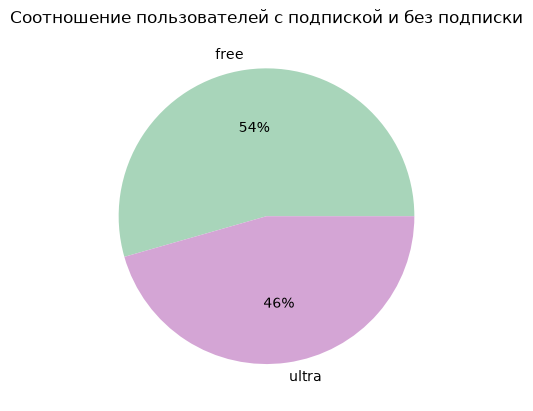

In [19]:
# Строим круговую диаграмму 
subscription_type_count.plot(
    kind = 'pie', # определяем тип графика (круговая диаграмма)
    title = 'Соотношение пользователей с подпиской и без подписки', # заголовок
    autopct = '%.0f%%', # процентные метки
    ylabel = '', # убираем подпись оси Y
    colors = ['#A8D5BA', '#D4A5D5'] # цвета секторов
)

plt.show()

#### Определение наиболее частого возраста пользователей

In [20]:
# Находим возраст с максимальным количеством пользователей
age_mode = df_users_go['age'].mode()[0]
print(f'Наиболее частый возраст пользователей: {age_mode} лет')

# Смотрим топ-5 самых частых возрастов
top_ages = df_users_go['age'].value_counts().head(5)
print('\nТоп-5 самых частых возрастов:')
print(top_ages)

Наиболее частый возраст пользователей: 25 лет

Топ-5 самых частых возрастов:
age
25    145
24    132
26    131
23    129
22    119
Name: count, dtype: int64


#### Визуализируем возрастные категории пользователей

In [21]:
# Определяем количество бинов
n_bins = (df_users_go['age'].max() - df_users_go['age'].min())
n_bins

np.int64(31)

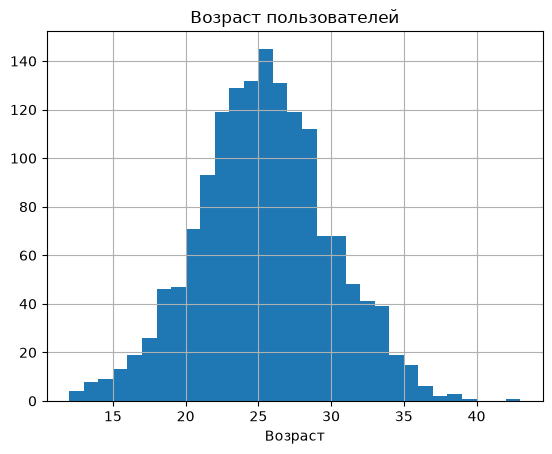

In [22]:
# Строим гистограмму по возрастам
df_users_go['age'].hist(bins = n_bins)
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.show()

#### Рассчитываем долю несовершеннолетних пользователей 

In [23]:
# Считаем количество пользователей < 18 лет
users_under_18_ratio = int((df_users_go['age'] < 18).mean() * 100)
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


#### Характеристики длительности поездки

In [24]:
duration_mean = int(round(df_rides_go['duration'].mean(), 0))
duration_std = int(round(df_rides_go['duration'].std(), 0))

duration_pct25 = int(round(df_rides_go['duration'].quantile(0.25), 0))
duration_pct75 = int(round(df_rides_go['duration'].quantile(0.75), 0))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


#### Промежуточный вывод по результатам исследовательского анализа данных 
В ходе исследовательского анализа данных были изучены ключевые характеристики пользовательской базы сервиса:

**Географическое распределение пользователей**

- Наибольшее количество пользователей сосредоточено в Пятигорске (219 человек), Екатеринбурге (204) и Ростове-на-Дону (198). Москва, несмотря на статус крупнейшего города, занимает лишь восьмое место по числу пользователей (168 человек). Это может указывать на более высокую конкуренцию в столице или специфику маркетинговой стратегии компании.

**Соотношение тарифов**

- Пользователи с бесплатным тарифом Free составляют большинство — 54% (835 человек), тогда как платная подписка Ultra оформлена у 46% пользователей (699 человек). Почти равное распределение говорит о здоровом балансе между платными и бесплатными пользователями.

**Возрастной профиль**

- Возрастной диапазон пользователей составляет от 12 до 43 лет. Наиболее частый возраст — 25 лет (145 пользователей). В топ-5 самых частых возрастов входят: 25 лет (145), 24 года (132), 26 лет (131), 23 года (129) и 22 года (119). Таким образом, ядро аудитории сосредоточено в возрастном интервале 22-26 лет, с пиком в 25 лет. Пользователи младше 18 лет составляют всего 5% от общего числа.

**Характеристики поездок**

- Средняя длительность поездки составляет 18 минут со стандартным отклонением 6 минут. Основная масса поездок (от 25-го до 75-го процентиля) укладывается в интервал от 14 до 22 минут. Это свидетельствует о том, что пользователи воспринимают самокат как средство для коротких и средних поездок, а не для длительных перемещений.

**Таким образом:**

- Пользовательская база сервиса представлена преимущественно молодыми экономически активными людьми в возрасте 22-26 лет (пик — 25 лет), с почти равным распределением между платным (46%) и бесплатным (54%) тарифами. Поездки носят умеренный по длительности характер (в среднем 18 минут), что формирует основу для дальнейшего расчета выручки и проверки гипотез о поведенческих различиях между тарифными группами.

---
# Объединение данных

#### Объединяем таблицы пользователей и поездок

In [25]:
# Объединяем два датафрейма
df = df_users_go.merge(df_rides_go, on = 'user_id', how = 'left')

In [26]:
# Проверяем 
df.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8


#### Присоединяем информацию о подписках

In [27]:
# Присоединяем к полученному датафрейму мноформацию о подписках из df_subscriptions_go
df = df.merge(df_subscriptions_go, on = 'subscription_type', how = 'left')

In [28]:
# Проверяем
df.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


#### Проверяем размеры объединённого датафрейма

In [29]:
# Выводим первые строки датафрейма
display(df.head())

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


#### Промежуточный вывод по результатам объединения данных
В ходе объединения данных выполнены следующие операции:
- Таблицы с пользователями (1565 записей) и поездками (18068 записей) объединены по идентификатору пользователя. Получен датафрейм, содержащий все поездки с полной информацией о каждом пользователе.
- К объединенным данным присоединена информация о стоимости поездок для каждого типа подписки: цена минуты, плата за старт и абонентская плата.

Объединение данных выполнено успешно. Все 18068 поездок теперь содержат полную информацию о пользователях и тарифах

# Анализ длительности поездок по типам подписки

#### Создаем вспомогательные датафреймы для пользователей с подпиской и без

In [30]:
# Создаем датафрейм для пользователей с подпиской
df_ultra = (df[df['subscription_type'] == 'ultra'])
df_ultra.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


In [31]:
# Создаем датафрейм для пользователей без подписки
df_free = (df[df['subscription_type'] == 'free'])
df_free.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,15,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,10,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17,2021-02-14,2,8,50,0


#### Визуализируем длительность поездок для обоих групп

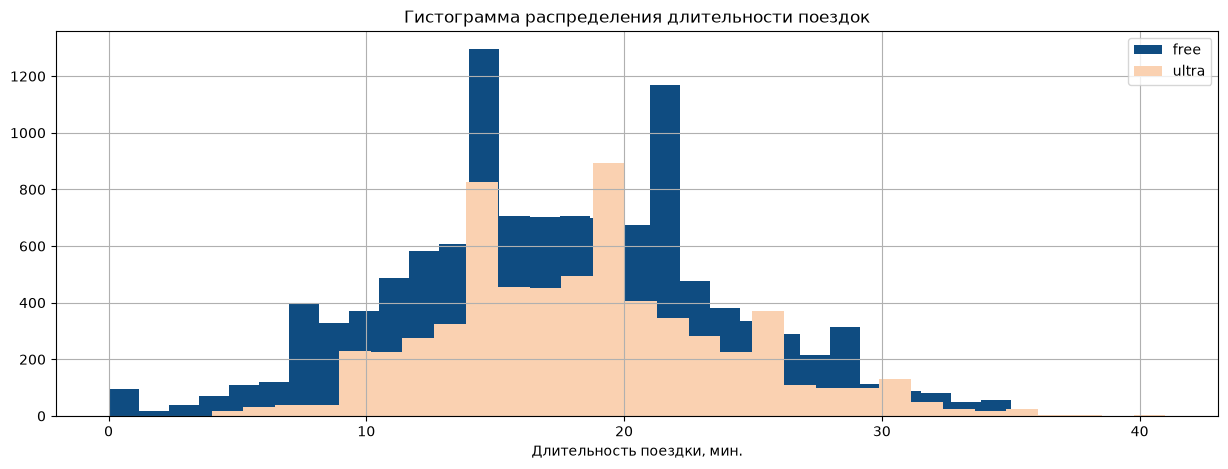

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [32]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))
df_free['duration'].hist(
    bins = 30,
    color='#0F4C81',
    label = 'free')

df_ultra['duration'].hist(
    bins=30,
    color='#FAD1B1',
    label='ultra')

plt.xlabel('Длительность поездки, мин.')

plt.title('Гистограмма распределения длительности поездок')

plt.legend()

plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

#### Промежуточный вывод по результатам анализа длительности поездок по типам подписки
В ходе анализа длительности поездок в разрезе типов подписки были получены следующие результаты:

**Распределение длительности поездок**

- Построена гистограмма распределения длительности поездок для пользователей с подпиской Ultra и без подписки Free. Визуальный анализ показывает, что распределения обеих групп имеют схожую форму, однако у подписчиков Ultra наблюдается небольшой сдвиг в сторону более длительных поездок.

**Сравнение средних значений**

- Средняя длительность поездки для пользователей с подпиской Ultra составляет 19 минут, тогда как для пользователей без подписки Free - 17 минут. Разница составляет 2 минуты в пользу подписчиков.

Общий вывод:

Пользователи с подпиской Ultra в среднем тратят на одну поездку больше времени, чем пользователи без подписки. Данное наблюдение требует статистической проверки для подтверждения его значимости. 

---
# Рассчет выручки

#### Группируем данные

In [33]:
df_gp = df.groupby(['user_id','name','subscription_type','month'], as_index = False)
df_gp.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,20,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,21,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,18,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,17,2021-11-27,11,8,50,0


#### Считаем агрегированные метрики
- `total_distance` - сумма значений в столбце distance.
- `total_duration` - сумма значений в столбце duration.
- `rides_count` - количество элементов в столбце duration.
- `subscription_type` - первое значение в группе для столбца subscription_type.
- `minute_price` - первое значение в группе для столбца minute_price.
- `start_ride_price` - первое значение в группе для столбца start_ride_price.
- `subscription_fee` - первое значение в группе для столбца subscription_fee.

In [34]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
)
df_agg.head()

,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199
1,1,Кира,4,754.159807,6,1,ultra,6,0,199
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199


#### Создаем функцию для подсчёта выручки
- `start_ride_price * rides_count` - выручка от начала каждой поездки.
- `minute_price * total_duration` - выручка за время использования.
- `subscription_fee` - фиксированная выручка от подписок.

In [35]:
def calculate_monthly_revenue(row):
    monthly_revenue = (
        row['start_ride_price'] * row['rides_count']
        +
        row['minute_price'] * row['total_duration']
        +
        row['subscription_fee']
    )
    return monthly_revenue

#### Создаем столбец с месячной выручкой на пользователя

In [36]:
df_agg['monthly_revenue'] = (df_agg.apply(calculate_monthly_revenue, axis=1))
df_agg.head()

,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_revenue
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199,451
1,1,Кира,4,754.159807,6,1,ultra,6,0,199,235
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199,469
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199,391
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199,517


#### Поиск пользователей с максимальной выручкой

In [37]:
top_user_id = (
    df_agg.groupby('user_id')['monthly_revenue']
    .sum()
    .idxmax()
)

display(
    df_agg.loc[
        df_agg['user_id'] == top_user_id,
        ['user_id',
         'name',
         'month',
         'rides_count',
         'monthly_revenue']
    ]
)

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


Промежуточный вывод по результатам расчета выручки
- Данные о поездках сгруппированы по пользователям и месяцам. Для каждого пользователя в разрезе месяцев рассчитаны агрегированные метрики.
- На основе параметров тарифов рассчитана месячная выручка для каждого пользователя.
- Определены пользователи с максимальной суммарной выручкой за весь период.

---
# Проверка гипотез

#### Создаем вспомогательную функцию для интерпретации результатов

Цель: Разработать универсальную функцию, которая будет автоматически интерпретировать результаты статистических тестов на основе p-value и заданного уровня значимости. Это позволит стандартизировать выводы по всем проверяемым гипотезам в проекте.

Описание:
- Критический уровень значимости alpha = 0.05 - стандартный порог для принятия решений в статистике.
- p_value - вероятность случайного возникновения различий
- Если p_value < alpha, результат статистически значим - принимаем альтернативную гипотезу.
- Если p_value >= alpha, значимых различий нет - нулевую гипотезу отвергнуть нельзя.

In [38]:
def print_stattest_results(p_value: float, alpha: float = 0.05):
    if p_value < alpha:
        print(
            f'Полученное значение p_value={p_value} '
            f'меньше критического уровня alpha={alpha}. '
            f'Принимаем альтернативную гипотезу.'
        )
    else:
        print(
            f'Полученное значение p_value={p_value} '
            f'больше критического уровня alpha={alpha}. '
            f'Опровергнуть нулевую гипотезу нельзя.'
        )

print_stattest_results(p_value=0.0001)

print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


#### Длительность для пользователей с подпиской и без

Цель: 
- Определить, тратят ли пользователи с платной подпиской Ultra больше времени на одну поездку по сравнению с пользователями бесплатного тарифа Free.

Гипотезы:
- Нулевая гипотеза (Н0): Среднее время поездки у пользователей с подпиской и без подписки одинаковое.
- Альтернативная гипотеза (Н1): Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

In [39]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative = 'greater')
p_value = results.pvalue
print_stattest_results(p_value)
ultra_mean_duration = round(ultra_duration.mean(), 2)
free_mean_duration = round(free_duration.mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.160068943561195e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


#### Промежуточный вывод:

Результаты одностороннего t-теста показывают, что **разница в длительности поездок статистически значима** (p-value ≈ 3.16e-35 < 0.05). Мы отклоняем нулевую гипотезу и принимаем альтернативную: **пользователи с подпиской Ultra в среднем тратят на поездки больше времени, чем пользователи без подписки** (18.55 минут против 17.39 минут). Это говорит о том, что платная подписка стимулирует пользователей проводить больше времени за рулем самоката, что может свидетельствовать о более высокой вовлеченности и лояльности этой группы.

#### Длительность поездки: больше или меньше критического значения

Цель: 
- Проверить, превышает ли средняя дистанция одной поездки у пользователей с подпиской Ultra пороговое значение в 3130 метров, которое считается оптимальным с точки зрения износа самоката.

Формулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Средняя дистанция поездки у пользователей с подпиской равна 3130 м.
- Альтернативная гипотеза (Н1): Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

In [40]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


#### Промежуточный вывод:

Результаты одностороннего t-теста показывают, что **разница между средней дистанцией поездок подписчиков и пороговым значением 3130 метров статистически незначима** (p-value ≈ 0.92 > 0.05). Мы не можем отвергнуть нулевую гипотезу - нет достаточных оснований утверждать, что подписчики проезжают в среднем больше 3130 метров за одну поездку. Это означает, что с точки зрения износа самокатов подписчики Ultra не создают дополнительной нагрузки по сравнению с установленным порогом.

#### Прибыль от пользователей с подпиской и без

Цель: 
- Определить, приносят ли пользователи с платной подпиской Ultra более высокую месячную выручку по сравнению с пользователями бесплатного тарифа Free.

Гипотезы:
- Нулевая гипотеза (Н0): Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.
- Альтернативная гипотеза (Н1): Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.

In [41]:
revenue_ultra = (df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue'])
revenue_free = (df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue'])

results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387872e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


#### Промежуточный вывод:

Результаты одностороннего t-теста показывают, что **разница в месячной выручке статистически значима** (p-value ≈ 1.73e-37 < 0.05). Мы отклоняем нулевую гипотезу и принимаем альтернативную: **пользователи с подпиской Ultra приносят в среднем более высокую месячную выручку, чем пользователи без подписки** (359 рублей против 322 рублей). Это ключевой бизнес-показатель, подтверждающий экономическую эффективность платной подписки: несмотря на более низкую стоимость минуты и отсутствие платы за старт, подписчики генерируют больше выручки за счет более активного использования сервиса.

---
#### Расчёт выборочного среднего и стандартного отклонения

Цель блока: 
- Рассчитать основные параметры распределения длительности поездок для пользователей с подпиской Ultra - среднее значение и стандартное отклонение. Эти параметры необходимы для дальнейшего моделирования нормального распределения.

In [42]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


#### Промежуточный вывод:

Для пользователей с подпиской Ultra средняя длительность одной поездки составляет 18.5 минут при стандартном отклонении 5.6 минут. Это означает, что основная масса поездок (в пределах одного стандартного отклонения) укладывается в интервал от 12.9 до 24.1 минуты. Полученные параметры будут использованы для построения нормального распределения и расчета вероятностей в следующих блоках.

#### Вычисляем значения функции распределения в точке (CDF)

Цель блока: 
- Определить вероятность того, что случайная поездка пользователя с подпиской Ultra продлится более 30 минут, используя нормальное распределение.

In [43]:
duration_norm_dist  = st.norm(loc = mu, scale = sigma)
prob = round(1 - duration_norm_dist.cdf(target_time), 3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


#### Промежуточный вывод:
Вероятность того, что поездка пользователя с подпиской Ultra продлится более 30 минут, составляет всего 2%. Это означает, что длительные поездки (свыше 30 минут) являются редким событием для данной группы пользователей. Полученный результат может быть полезен для бизнес-планирования, например, при разработке тарифных ограничений или специальных предложений для самых активных пользователей.

#### Вероятность для интервала (CDF)

Цель блока: 
- Определить, какой процент пользователей с подпиской Ultra совершает поездки длительностью от 20 до 30 минут. Это может помочь в оценке потенциальной аудитории для целевых промоакций.

In [44]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


#### Промежуточный вывод:

Вероятность того, что поездка пользователя с подпиской Ultra продлится от 20 до 30 минут, составляет 37.7%. Данная группа пользователей может быть интересной целью для промоакций или специальных предложений, так как они демонстрируют умеренно высокую активность и могут быть мотивированы на увеличение времени использования сервиса.

#### Определение критической дистанции поездок (PPF)

Цель: 
- Рассчитать расстояние, ниже которого находятся 90% всех поездок (90-й процентиль). Это значение может использоваться для установления порога, превышение которого будет сопровождаться дополнительной платой, с целью контроля износа самокатов.

In [45]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(loc = mu, scale=sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


#### Промежуточный вывод:

Критическая дистанция, ниже которой находятся 90% всех поездок (вне зависимости от типа подписки), составляет 4501.94 метра. Это означает, что только 10% поездок превышают данное расстояние. Установление этого порога как лимита для дополнительной платы может быть обоснованным бизнес-решением: оно затронет лишь небольшую долю поездок, но при этом поможет контролировать износ самокатов и управлять операционными расходами.

# Итоговый вывод и рекомендации для бизнеса

**Цель исследования**

В рамках проекта был проведен анализ данных пользователей сервиса проката самокатов с целью оценки эффективности платной подписки Ultra и выработки рекомендаций по развитию продукта. Анализ включал изучение демографического профиля пользователей, поведенческих паттернов, расчет выручки и проверку статистических гипотез.

---

**Краткая характеристика пользовательской базы**

- **Численность пользователей:** 1534 человека после очистки от дубликатов.
- **Соотношение тарифов:** 54% - бесплатный тариф Free, 46% - платная подписка Ultra.
- **Возрастной профиль:** ядро аудитории - молодые люди в возрасте 22–26 лет (пик — 25 лет), доля несовершеннолетних - всего 5%.
- **География:** наибольшее количество пользователей зафиксировано в Пятигорске, Екатеринбурге и Ростове-на-Дону.

---

**Результаты проверки гипотез**
- Подписчики Ultra тратят на поездки в среднем на 2 минуты больше. Это говорит о более высокой вовлеченности и активности пользователей платного тарифа.
- Нет статистически значимых оснований утверждать, что подписчики Ultra проезжают больше 3130 метров за одну поездку. Таким образом, с точки зрения износа самокатов подписчики Ultra не создают дополнительной нагрузки.
- Подписчики Ultra приносят в среднем на 37 рублей больше выручки в месяц, несмотря на отсутствие платы за старт и более низкую стоимость минуты. Это ключевой аргумент в пользу экономической эффективности подписки.

Анализ подтвердил, что платная подписка Ultra является экономически эффективным инструментом:

---

**Рекомендации для бизнеса**

**Активно продвигать подписку Ultra**

- Подписка доказала свою экономическую эффективность. Рекомендуется усилить маркетинговые кампании, направленные на конвертацию пользователей Free в Ultra, с акцентом на выгоды для активных пользователей.

**Пересмотреть маркетинговые сообщения**

- Так как гипотеза о дистанции не подтвердилась, не стоит делать акцент на "дальних поездках" в рекламных материалах. Вместо этого следует фокусироваться на **удобстве**, **экономии** и **отсутствии платы за старт** - именно это является ключевыми ценностями для подписчиков.

**Разработать программу конвертации (из Free в Ultra)**
- Проанализировать поведение Free-пользователей с наибольшей активностью.
- Предложить им персонализированные предложения по переходу на Ultra.
- Рассмотреть внедрение бесплатного пробного периода подписки.

**Использовать данные о вероятностях поездок**

Анализ распределения длительности поездок показал:
- Вероятность поездки более 30 минут составляет **2%**.
- Вероятность поездки в интервале 20–30 минут - **37.7%**.

Это можно использовать для разработки таргетированных промоакций: например, предложить скидку пользователям, чьи поездки укладываются в интервал 20–30 минут, чтобы стимулировать их увеличить время использования.

---
**Таким образом**, исследование подтвердило, что платная подписка Ultra положительно влияет на поведение пользователей и увеличивает выручку сервиса. Рекомендованные меры по продвижению подписки и конвертации пользователей Free в Ultra позволят компании укрепить финансовые показатели и повысить лояльность клиентской базы.